# CIFAR-10 Inference Visualization

Load the best saved checkpoint, run it on a random image from the CIFAR-10 test set, and visualize the predicted class probabilities.

Re-run the **"Sample, predict, and plot"** cell to try a new random image each time.

In [ ]:
import os
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms

# ml/*.py import each other with bare names (e.g. `from config import Config`),
# so ml/ needs to be on sys.path rather than installed as a package.
ML_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "ml"))
if ML_DIR not in sys.path:
    sys.path.insert(0, ML_DIR)

from config import Config
from dataset import CIFAR10_MEAN, CIFAR10_STD
from model import SimpleCNN

## Load config, test set, and the best checkpoint

In [ ]:
cfg = Config()
# Config's paths ("./data", "./checkpoints/...") are relative to the repo root,
# not this notebook's cwd, so resolve them against ML_DIR's parent.
REPO_ROOT = os.path.dirname(ML_DIR)
cfg.data_dir = os.path.join(REPO_ROOT, "data")
cfg.checkpoint_path = os.path.join(REPO_ROOT, "checkpoints", "best_model.pt")

device = torch.device(cfg.device)
print(f"Using device: {device}")

# Same test-time transform as dataset.py's get_dataloaders (no augmentation).
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_set = torchvision.datasets.CIFAR10(
    root=cfg.data_dir, train=False, download=True, transform=test_transform
)
print(f"Test set size: {len(test_set)}")

model = SimpleCNN(num_classes=len(cfg.classes)).to(device)
checkpoint = torch.load(cfg.checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(
    f"Loaded checkpoint from epoch {checkpoint['epoch']} "
    f"(val_acc at save time = {checkpoint['val_acc']:.4f})"
)

## Helper: denormalize a tensor back to a displayable image

In [3]:
_mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
_std = torch.tensor(CIFAR10_STD).view(3, 1, 1)


def denormalize(img_tensor: torch.Tensor) -> np.ndarray:
    """Reverse the Normalize(CIFAR10_MEAN, CIFAR10_STD) transform for display."""
    img = img_tensor.cpu() * _std + _mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

## Sample, predict, and plot

Re-run this cell to pick a new random test image each time.

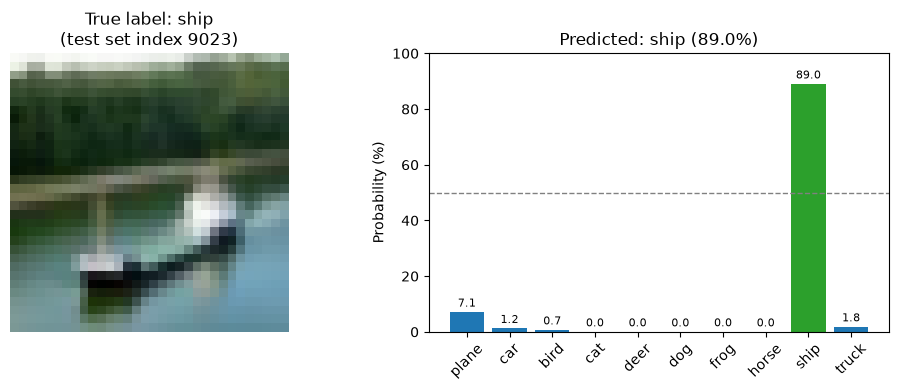

True: ship | Predicted: ship (89.0%) -> correct


In [20]:
CONFIDENCE_THRESHOLD = 0.5  # below this, treat the top prediction as "uncertain" rather than committing

idx = random.randrange(len(test_set))
img_tensor, true_label_idx = test_set[idx]
true_label = cfg.classes[true_label_idx]

with torch.no_grad():
    logits = model(img_tensor.unsqueeze(0).to(device))
    probs = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

pred_label_idx = int(probs.argmax())
pred_label = cfg.classes[pred_label_idx]
pred_confidence = probs[pred_label_idx]
is_uncertain = pred_confidence < CONFIDENCE_THRESHOLD
is_correct = pred_label_idx == true_label_idx

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))

# Raw image + true label
ax_img.imshow(denormalize(img_tensor))
ax_img.set_title(f"True label: {true_label}\n(test set index {idx})")
ax_img.axis("off")

# Predicted class probabilities
bar_colors = [
    ("tab:orange" if is_uncertain else "tab:green") if i == pred_label_idx else "tab:blue"
    for i in range(len(cfg.classes))
]
bars = ax_bar.bar(cfg.classes, probs * 100, color=bar_colors)
ax_bar.axhline(CONFIDENCE_THRESHOLD * 100, color="gray", linestyle="--", linewidth=1)
ax_bar.set_ylabel("Probability (%)")
ax_bar.set_ylim(0, 100)
title = "Uncertain" if is_uncertain else f"Predicted: {pred_label}"
ax_bar.set_title(f"{title} ({pred_confidence * 100:.1f}%)")
ax_bar.tick_params(axis="x", rotation=45)
ax_bar.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)

plt.tight_layout()
plt.show()

if is_uncertain:
    print(f"True: {true_label} | Prediction uncertain (top guess {pred_label} at {pred_confidence * 100:.1f}%, below {CONFIDENCE_THRESHOLD * 100:.0f}% threshold)")
else:
    result = "correct" if is_correct else "WRONG"
    print(f"True: {true_label} | Predicted: {pred_label} ({pred_confidence * 100:.1f}%) -> {result}")